# Clustering artists - external

Initial exploration of clustering and labeling artists based on text embeddings of institutional categorization and exhibition groupings, downloaded from Google Colab

In [1]:
!wget -q https://github.com/PSAM-5020-2026S-A/5020-utils/raw/main/src/data_utils.py

In [89]:
import json
import pandas as pd
import numpy as np
import spacy
import umap
import re
import textwrap
import ast

from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction import text as sklearn_text
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt
import matplotlib.cm as cm

from google.colab import files
from data_utils import balance_score, distance_score, silhouette_score, display_silhouette_plots

# Load data + initialize model

In [3]:
# load data
artists_df = pd.read_csv('/content/artists.csv')
exhibitions_df = pd.read_csv('/content/exhibitions.csv')
artworks_df = pd.read_csv('/content/artworks.csv')
institution_words_df = pd.read_csv('/content/institution_words.csv')

In [4]:
nlp = spacy.load("en_core_web_sm")
model = SentenceTransformer("nomic-ai/nomic-embed-text-v1.5", trust_remote_code=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/255 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/140 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/58.0 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/547M [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/695 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/286 [00:00<?, ?B/s]

# Helpers


*   semantic_chunk
*   get_word_weights



In [7]:
# based on semantic similarity between sentences
def semantic_chunk(text, threshold=0.75, min_sentences=1, min_chars=100, max_sentences=3):
    doc = nlp(text)
    sentences = [sent.text.strip() for sent in doc.sents if sent.text.strip()]

    if len(sentences) <= min_sentences:
        return [text]

    # embed sentences to compare similarity
    embeddings = model.encode(
        [f"search_document: {s}" for s in sentences],
        convert_to_numpy=True,
        normalize_embeddings=True
    )

    chunks = []
    current_chunk = [sentences[0]]

    for i in range(1, len(sentences)):
        # compare current sentence to mean of the current chunk
        chunk_embedding = embeddings[i - len(current_chunk):i].mean(axis=0, keepdims=True)
        sim = cosine_similarity(chunk_embedding, embeddings[i:i+1])[0][0]

        current_char_count = sum(len(s) for s in current_chunk)

        meets_min_sentences = len(current_chunk) >= min_sentences
        meets_min_chars = current_char_count >= min_chars      # ← new
        semantically_different = sim < threshold
        too_long = len(current_chunk) >= max_sentences

        should_split = (semantically_different or too_long) and meets_min_sentences and meets_min_chars


        if should_split:
            chunks.append(" ".join(current_chunk))
            current_chunk = [sentences[i]]
        else:
            current_chunk.append(sentences[i])

    if current_chunk:
        chunks.append(" ".join(current_chunk))

    return chunks

In [26]:
def get_word_weights(doc, vectorizer):
  doc_tfidf = vectorizer.transform([doc])
  feature_names = vectorizer.get_feature_names_out()

  df = pd.DataFrame(doc_tfidf[0].T.todense(),
                    index=feature_names,
                    columns=["tfidf"])

  ret = df.sort_values(by="tfidf", ascending=False)

  return ret.head(3).index.tolist()


# Prep data

In [105]:
# get all exhibition text
exhibitions_df['full_text'] = exhibitions_df['name'].fillna('') + ". " + exhibitions_df['description'].fillna('')

In [106]:
# chunk exhibition text
inst_chunk_data = []
for idx, row in exhibitions_df.iterrows():
    text = row['full_text']
    if not text.strip():
        continue

    chunks = semantic_chunk(text)
    for chunk in chunks:
        inst_chunk_data.append({
            'source_idx': row['id'],
            'text_type': 'exhibition',
            'chunk_text': chunk,
            'artists': row['artists']
        })

In [107]:
# need to do the same with artworks_df alt_text and descriptions and institution_words_df and add all chunks to one df to embed

# get all institutional artwork text
institution_words_df['full_text'] = institution_words_df['text'].fillna('')

for idx, row in institution_words_df.iterrows():
    text = row['full_text']
    if not text.strip():
        continue

    chunks = semantic_chunk(text)
    for chunk in chunks:
        inst_chunk_data.append({
            'source_idx': row['id'],
            'text_type': 'museum',
            'chunk_text': chunk,
            'artists': [row['artist']]
        })

In [108]:
def convert_str_to_arr(str_arr):
    if isinstance(str_arr, str):
        return ast.literal_eval(str_arr)
    else:
        return str_arr

In [109]:
inst_chunks_df = pd.DataFrame(inst_chunk_data)
inst_chunks_df["artists"] = inst_chunks_df["artists"].apply(lambda x: convert_str_to_arr(x))
print(f"length {len(inst_chunks_df)}")
inst_chunks_df


length 206


,source_idx,text_type,chunk_text,artists
0,0,exhibition,"Part Asian, 100% Hapa. ha • pa (ha’pa)\nadj. s...",[4]
1,0,exhibition,n. slang. a person of such ancestry. [der./haw...,[4]
2,0,exhibition,"part asian, 100% hapa is an exhibition of port...",[4]
3,0,exhibition,Originally a derogatory label derived from the...,[4]
4,0,exhibition,This exhibition was first displayed at the Nat...,[4]
...,...,...,...,...
201,IT37,museum,"In multiple works, Tsang incorporates audiovis...",[9]
202,IT37,museum,"Her 2008 video The Shape of a Right Statement,...",[9]
203,IT37,museum,By restaging Baggs’s words as a form of video ...,[9]
204,IT38,museum,"American, born 1982",[9]


# Initial exhibition groups - cluster labels

In [40]:
new_stop_words = ["biennale", "biennial", "museum", "exhibition", "baratta", "italian", "asian", "american", "chinese", "year"]
custom_stop_words = list(sklearn_text.ENGLISH_STOP_WORDS.union(new_stop_words))

# add all the artist first and last names to the stop words list
for idx, row in artists_df.iterrows():
    # split by first and last name
    names = re.split(r'[- ]', row["name"])

    for name in names:
      custom_stop_words.append(name.lower())

for idx, row in exhibitions_df.iterrows():
  locations = re.split(r'[, ]', row["location"])

  for location in locations:
    custom_stop_words.append(location.lower())

In [41]:
all_corpus = exhibitions_df['full_text'].tolist()

vectorizer = TfidfVectorizer(stop_words=custom_stop_words)

tfidf_matrix = vectorizer.fit_transform(all_corpus)

In [45]:
# get word weights for each row in exhibitions
exhibitions_df["labels"] = exhibitions_df.apply(lambda row: get_word_weights(row['full_text'], vectorizer), axis=1)
exhibitions_df["labels"]


,labels
0,"[hapa, 100, ancestry]"
1,"[mixed, war, race]"
2,"[citizen, universe, life]"
3,"[archaic, modern, ancient]"
4,"[orient, dis, diaspora]"
5,"[legacies, artists, art]"
6,"[east, like, west]"
7,"[international, world, countries]"
8,"[ideologies, global, authoritarian]"
9,"[documentary, filmmaker, dead]"


In [47]:
# download w labels
exhibitions_df.to_csv('exhibitions_with_labels.csv', index=False)

files.download('exhibitions_with_labels.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Embed all institutional text

In [110]:
# add to array
inst_chunk_texts = ["clustering: " + t for t in inst_chunks_df["chunk_text"].tolist()]

# embed
inst_embeddings = model.encode(
    inst_chunk_texts,
    batch_size=64,
    convert_to_tensor=True,
    show_progress_bar=True,
    normalize_embeddings=True
)

inst_embeddings_np = inst_embeddings.cpu().numpy()
len(inst_embeddings_np)

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

206

# Cluster

FOR NUM CLUSTERS  6  --------------------
score:  -50.29926681518555
distance score:  0.48490968
silhouette score:  0.088927075
balance score:  0.8135922330097087


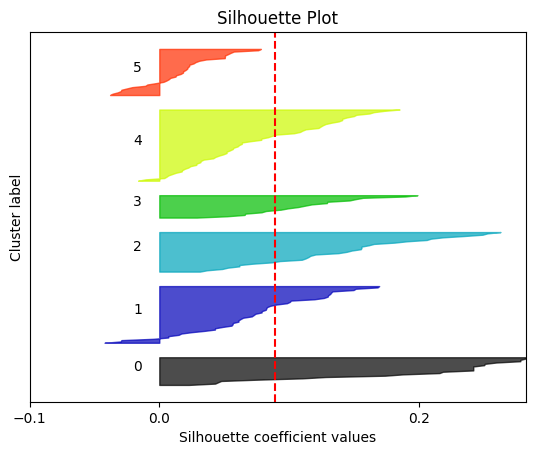

In [128]:
n_clusters = 6

kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init="auto")
cluster_labels = kmeans.fit_predict(inst_embeddings_np)

sc = kmeans.score(inst_embeddings_np)
distance_sc = distance_score(inst_embeddings_np, cluster_labels)
silhouette_sc = silhouette_score(inst_embeddings_np, cluster_labels)
balance_sc = balance_score(cluster_labels)
print("FOR NUM CLUSTERS ", n_clusters, " --------------------")
print("score: ", sc)
print("distance score: ", distance_sc)
print("silhouette score: ", silhouette_sc)
print("balance score: ", balance_sc)

display_silhouette_plots(inst_embeddings_np, cluster_labels)

In [129]:
inst_3d_reducer = umap.UMAP(n_components=3, metric="cosine", random_state=42)
inst_embeddings_3d = inst_3d_reducer.fit_transform(inst_embeddings_np)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


# Plot

In [130]:
inst_chunks_df["umap_x"] = inst_embeddings_3d[:, 0]
inst_chunks_df["umap_y"] = inst_embeddings_3d[:, 1]
inst_chunks_df["umap_z"] = inst_embeddings_3d[:, 2]
inst_chunks_df["cluster"] = cluster_labels

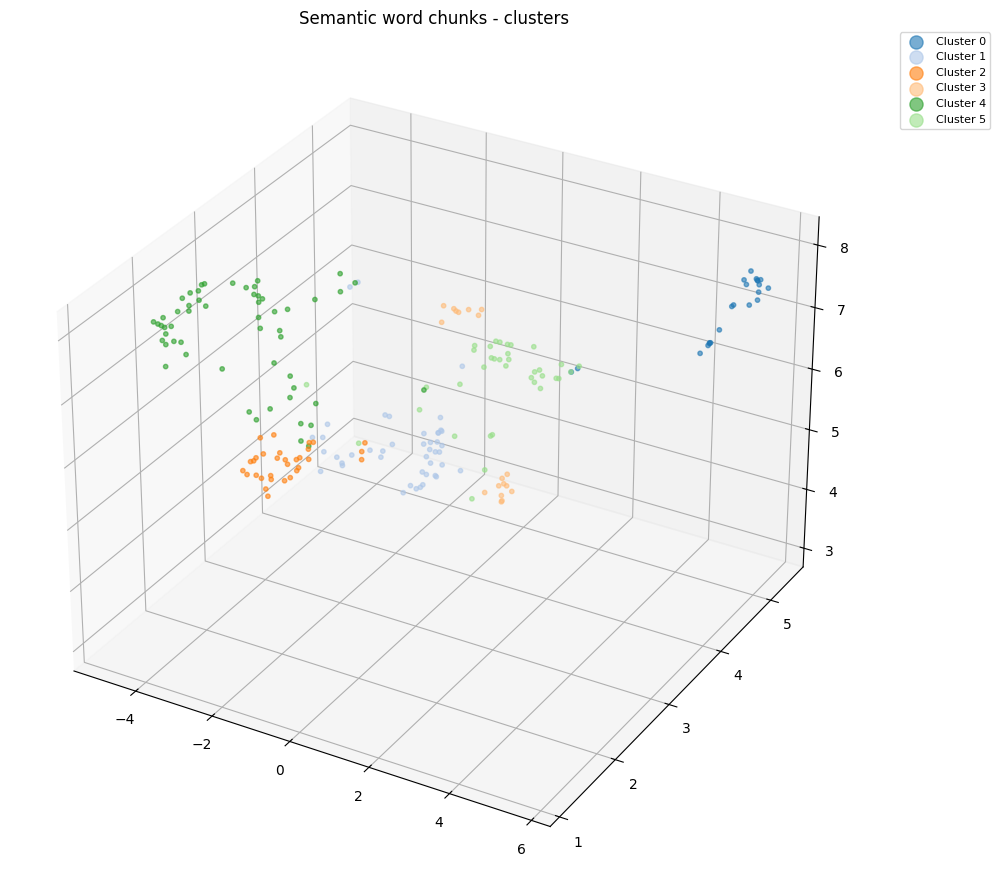

In [131]:
palette = (
    [cm.tab20(i) for i in range(20)] +
    [cm.tab20b(i) for i in range(20)] +
    [cm.tab20c(i) for i in range(20)]
)
colors = palette[:n_clusters]

fig = plt.figure(figsize=(14, 9))
ax = fig.add_subplot(111, projection="3d")

for cluster_id, color in zip(sorted(inst_chunks_df["cluster"].unique()), colors):
    mask = inst_chunks_df["cluster"] == cluster_id
    ax.scatter(
        inst_chunks_df.loc[mask, "umap_x"],
        inst_chunks_df.loc[mask, "umap_y"],
        inst_chunks_df.loc[mask, "umap_z"],
        c=[color],
        label=f"Cluster {cluster_id}",
        alpha=0.6,
        s=10
    )

ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.05, 1),
    borderaxespad=0,
    markerscale=3,
    fontsize=8
)
ax.set_title("Semantic word chunks - clusters")
plt.tight_layout()
plt.show()

# Examine clusters

In [132]:
# distances from each point all cluster centers
centers = kmeans.cluster_centers_
all_distances = euclidean_distances(inst_embeddings_np, centers)

# lookup embed --> text
lookup_df = inst_chunks_df[["chunk_text", "source_idx", "text_type", "artists"]].reset_index(drop=True)

# rows = clusters, columns = points
distance_df = pd.DataFrame(
    all_distances.T,
    index=[f"cluster_{c}" for c in range(n_clusters)]
)
distance_df

,0,1,2,3,4,5,6,7,8,9,...,196,197,198,199,200,201,202,203,204,205
cluster_0,0.541617,0.578466,0.588150,0.654477,0.703368,0.649724,0.750408,0.752096,0.672191,0.670877,...,0.713210,0.768820,0.748474,0.695813,0.781899,0.753576,0.730942,0.745123,0.404244,0.503428
cluster_1,0.771857,0.669245,0.609389,0.763715,0.562445,0.666266,0.699804,0.689920,0.660371,0.621394,...,0.424966,0.644957,0.605429,0.654512,0.657874,0.599214,0.643801,0.636213,0.734820,0.757804
cluster_2,0.688123,0.626414,0.605411,0.700261,0.650656,0.639661,0.745030,0.744189,0.663112,0.608085,...,0.538504,0.679851,0.603414,0.673026,0.674247,0.665089,0.626328,0.654196,0.700088,0.732967
cluster_3,0.677783,0.648767,0.555870,0.703882,0.658522,0.609041,0.744404,0.719235,0.657162,0.560699,...,0.582254,0.515973,0.419912,0.496601,0.493685,0.471566,0.486822,0.596254,0.726402,0.764120
cluster_4,0.740144,0.644727,0.622966,0.755705,0.651336,0.658761,0.709434,0.721293,0.685537,0.619774,...,0.561525,0.684068,0.632289,0.664756,0.691435,0.618183,0.672796,0.657921,0.708432,0.753171
cluster_5,0.558998,0.513658,0.458403,0.573626,0.531125,0.462908,0.655329,0.633280,0.570975,0.416255,...,0.586176,0.600698,0.578822,0.567333,0.593348,0.562424,0.588533,0.561006,0.659812,0.720893


In [133]:
lookup_df

,chunk_text,source_idx,text_type,artists
0,"Part Asian, 100% Hapa. ha • pa (ha’pa)\nadj. s...",0,exhibition,[4]
1,n. slang. a person of such ancestry. [der./haw...,0,exhibition,[4]
2,"part asian, 100% hapa is an exhibition of port...",0,exhibition,[4]
3,Originally a derogatory label derived from the...,0,exhibition,[4]
4,This exhibition was first displayed at the Nat...,0,exhibition,[4]
...,...,...,...,...
201,"In multiple works, Tsang incorporates audiovis...",IT37,museum,[9]
202,"Her 2008 video The Shape of a Right Statement,...",IT37,museum,[9]
203,By restaging Baggs’s words as a form of video ...,IT37,museum,[9]
204,"American, born 1982",IT38,museum,[9]


In [134]:
# build artist lookup dictionary
artist_id_to_name = artists_df.set_index("id")["name"].to_dict()

def map_artist_names(artist_data):
    names = [artist_id_to_name.get(int(a_id), "Unknown") for a_id in artist_data]
    return ", ".join(names)

# Apply the mapping to the already existing lookup_df
lookup_df["artist_name"] = lookup_df["artists"].apply(map_artist_names)
display(lookup_df.head())


,chunk_text,source_idx,text_type,artists,artist_name
0,"Part Asian, 100% Hapa. ha • pa (ha’pa)\nadj. s...",0,exhibition,[4],Kip Fulbeck
1,n. slang. a person of such ancestry. [der./haw...,0,exhibition,[4],Kip Fulbeck
2,"part asian, 100% hapa is an exhibition of port...",0,exhibition,[4],Kip Fulbeck
3,Originally a derogatory label derived from the...,0,exhibition,[4],Kip Fulbeck
4,This exhibition was first displayed at the Nat...,0,exhibition,[4],Kip Fulbeck


In [135]:
for c in range(n_clusters):
    distances_to_c = all_distances[:, c]
    top_indices = np.argsort(distances_to_c)[:5]

    print(f"\n{'='*60}")
    print(f"CLUSTER {c}")
    for rank, idx in enumerate(top_indices, 1):
        assigned_cluster = cluster_labels[idx]
        dist = distances_to_c[idx]
        row = lookup_df.iloc[idx]
        print(f"\n  #{rank} | point: {idx} (distance: {dist:.4f} | assigned to cluster: {assigned_cluster} | artist: {row['artist_name']})")
        wrapped = textwrap.fill(row['chunk_text'], width=80, initial_indent="  ", subsequent_indent="  ")
        print(wrapped)


CLUSTER 0

  #1 | point: 192 (distance: 0.3859 | assigned to cluster: 0 | artist: Sarah Sze)
  Asian American, female

  #2 | point: 190 (distance: 0.3864 | assigned to cluster: 0 | artist: Sarah Sze)
  American, b. 1969

  #3 | point: 79 (distance: 0.3952 | assigned to cluster: 0 | artist: Laurel Nakadate)
  American, born 1975

  #4 | point: 76 (distance: 0.3952 | assigned to cluster: 0 | artist: Amanda Ross-Ho)
  American, born 1975

  #5 | point: 80 (distance: 0.3984 | assigned to cluster: 0 | artist: Laurel Nakadate)
  American

CLUSTER 1

  #1 | point: 33 (distance: 0.3997 | assigned to cluster: 1 | artist: Isamu Noguchi)
  In addition to aesthetic concerns such as figuration, abstraction and
  materiality, the exhibition tracks how these artists addressed migration,
  displacement, racism, cultural autonomy, Western imperialism, societal
  violence, and representations of sexuality and gender through the decades.

  #2 | point: 59 (distance: 0.4181 | assigned to cluster: 1 | ar

# All institutional text - cluster labels

In [140]:
addl_stop_words = ["adj", "years", "ming", "dariotis"]
stop_words_for_cluster = custom_stop_words + addl_stop_words

In [141]:
# combines all words in a cluster into one big string
cluster_texts = []
for c in range(n_clusters):
    mask = inst_chunks_df["cluster"] == c
    combined = " ".join(inst_chunks_df.loc[mask, "chunk_text"].tolist())
    cluster_texts.append(combined)

cluster_vectorizer = TfidfVectorizer(stop_words=stop_words_for_cluster, max_features=1000, ngram_range=(1,2))
cluster_tfidf_matrix = cluster_vectorizer.fit_transform(cluster_texts)
feature_names = cluster_vectorizer.get_feature_names_out()

top_n = 5
for c in range(n_clusters):
    top_indices = np.argsort(tfidf_matrix[c].toarray()[0])[::-1][:top_n]
    keywords = [feature_names[i] for i in top_indices]
    print(f"Cluster {c}: {', '.join(keywords)}")

Cluster 0: challenges history, challenging, contemporary, constructions, consider
Cluster 1: adjustments, workshop, world today, world different, familiar
Cluster 2: builds history, ball, josef albers, examines, child mixed
Cluster 3: designer, migration, baggs, roots pacific, bmc
Cluster 4: educator, adjustments, ancient, calligraphy juxtaposition, classification
Cluster 5: race, inner, took place, black, volume


# Results

In [143]:
own_center_distances = all_distances[range(len(cluster_labels)), cluster_labels]

# Closest OTHER cluster center — mask out the assigned cluster then take the min
masked = all_distances.copy()
masked[range(len(cluster_labels)), cluster_labels] = np.inf
closest_other_cluster = np.argmin(masked, axis=1)
closest_other_cluster_distance = masked[range(len(cluster_labels)), closest_other_cluster]  # ← add this


results_df = pd.DataFrame({
    "point":                 range(len(cluster_labels)),
    "cluster":               cluster_labels,
    "distance_to_center":    own_center_distances,
    "closest_other_cluster": closest_other_cluster,
    "distance_to_closest":   closest_other_cluster_distance,
    "chunk_text":            lookup_df["chunk_text"].values,
    "artists":             lookup_df["artists"].values,
    "source_idx":             lookup_df["source_idx"].values,
})

print(results_df.shape)
results_df.head()

(206, 8)


,point,cluster,distance_to_center,closest_other_cluster,distance_to_closest,chunk_text,artists,source_idx
0,0,0,0.541617,5,0.558998,"Part Asian, 100% Hapa. ha • pa (ha’pa)\nadj. s...",[4],0
1,1,5,0.513658,0,0.578466,n. slang. a person of such ancestry. [der./haw...,[4],0
2,2,5,0.458403,3,0.555870,"part asian, 100% hapa is an exhibition of port...",[4],0
3,3,5,0.573626,0,0.654477,Originally a derogatory label derived from the...,[4],0
4,4,5,0.531125,1,0.562445,This exhibition was first displayed at the Nat...,[4],0


In [145]:
filename = 'inst_wds_clustered_' + str(n_clusters) + '.csv'

results_df.to_csv(filename, index=False)

files.download(filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Redo for n clusters

In [156]:
def run_clustering_and_evaluate(embeddings, n_clusters):
    # Cluster
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init="auto")
    cluster_labels = kmeans.fit_predict(embeddings)

    # Evaluate
    sc = kmeans.score(embeddings)
    distance_sc = distance_score(embeddings, cluster_labels)
    silhouette_sc = silhouette_score(embeddings, cluster_labels)
    balance_sc = balance_score(cluster_labels)

    print(f"\n{'='*80}")
    print(f"FOR NUM CLUSTERS {n_clusters} --------------------")
    print("score: ", sc)
    print("distance score: ", distance_sc)
    print("silhouette score: ", silhouette_sc)
    print("balance score: ", balance_sc)

    display_silhouette_plots(embeddings, cluster_labels)

    return kmeans, cluster_labels

In [157]:
def plot_clusters_3d(embeddings_np, cluster_labels, n_clusters, df_source):
    # Reduce dimensions for plotting
    reducer_3d = umap.UMAP(n_components=3, metric="cosine", random_state=42)
    embeddings_3d = reducer_3d.fit_transform(embeddings_np)

    plot_df = df_source.copy()
    plot_df["umap_x"] = embeddings_3d[:, 0]
    plot_df["umap_y"] = embeddings_3d[:, 1]
    plot_df["umap_z"] = embeddings_3d[:, 2]
    plot_df["cluster"] = cluster_labels

    # Plot
    palette = (
        [cm.tab20(i) for i in range(20)] +
        [cm.tab20b(i) for i in range(20)] +
        [cm.tab20c(i) for i in range(20)]
    )
    colors = palette[:n_clusters]

    fig = plt.figure(figsize=(10, 6))
    ax = fig.add_subplot(111, projection="3d")

    for cluster_id, color in zip(sorted(plot_df["cluster"].unique()), colors):
        mask = plot_df["cluster"] == cluster_id
        ax.scatter(
            plot_df.loc[mask, "umap_x"],
            plot_df.loc[mask, "umap_y"],
            plot_df.loc[mask, "umap_z"],
            c=[color],
            label=f"Cluster {cluster_id}",
            alpha=0.6,
            s=10
        )

    ax.legend(loc="upper left", bbox_to_anchor=(1.05, 1), borderaxespad=0, markerscale=3, fontsize=8)
    ax.set_title(f"Clusters (k={n_clusters})")
    plt.tight_layout()
    plt.show()

In [158]:
def examine_top_points(embeddings_np, kmeans, cluster_labels, df_source, n_clusters):
    centers = kmeans.cluster_centers_
    all_distances = euclidean_distances(embeddings_np, centers)

    # print(f"\n--- Top chunks closest to centers (k={n_clusters}) ---")
    for c in range(n_clusters):
        distances_to_c = all_distances[:, c]
        top_indices = np.argsort(distances_to_c)[:5]

        # print(f"\nCLUSTER {c}")
        for rank, idx in enumerate(top_indices, 1):
            dist = distances_to_c[idx]
            row = df_source.iloc[idx]
            artist_info = row.get('artist_name', 'Unknown')
            # print(f"  #{rank} | distance: {dist:.4f} | artist: {artist_info}")
            wrapped = textwrap.fill(row['chunk_text'], width=80, initial_indent="    ", subsequent_indent="    ")
            # print(wrapped)

    return all_distances

In [159]:
def extract_cluster_keywords(df_source, cluster_labels, n_clusters, stop_words):
    temp_df = df_source.copy()
    temp_df["cluster"] = cluster_labels

    cluster_texts = []
    for c in range(n_clusters):
        mask = temp_df["cluster"] == c
        combined = " ".join(temp_df.loc[mask, "chunk_text"].tolist())
        cluster_texts.append(combined)

    vectorizer = TfidfVectorizer(stop_words=stop_words, token_pattern=r'\b\w*[a-zA-Z]\w*\b', max_features=1000, ngram_range=(1,2))
    tfidf_matrix = vectorizer.fit_transform(cluster_texts)
    feature_names = vectorizer.get_feature_names_out()

    # print(f"\n--- Top Keywords (k={n_clusters}) ---")
    top_n = 5
    cluster_keywords = {}
    for c in range(n_clusters):
        top_indices = np.argsort(tfidf_matrix[c].toarray()[0])[::-1][:top_n]
        keywords = [feature_names[i] for i in top_indices]
        # print(f"Cluster {c}: {', '.join(keywords)}")
        cluster_keywords[str(c)] = keywords

    return cluster_keywords

In [160]:
def get_cluster_results_df(df_source, cluster_labels, all_distances, n_clusters):
    own_center_distances = all_distances[range(len(cluster_labels)), cluster_labels]

    masked = all_distances.copy()
    masked[range(len(cluster_labels)), cluster_labels] = np.inf
    closest_other_cluster = np.argmin(masked, axis=1)
    closest_other_cluster_distance = masked[range(len(cluster_labels)), closest_other_cluster]

    results_df = pd.DataFrame({
        "point":                 range(len(cluster_labels)),
        "cluster":               cluster_labels,
        "distance_to_center":    own_center_distances,
        # "closest_other_cluster": closest_other_cluster,
        # "distance_to_closest":   closest_other_cluster_distance,
        "chunk_text":            df_source["chunk_text"].values,
        "artists":               df_source["artists"].values,
        "source_idx":            df_source["source_idx"].values,
    })

    for c in range(n_clusters):
      results_df[f"dist_to_cluster_{c}"] = all_distances[:, c]

    if 'artist_name' in df_source.columns:
        results_df["artist_name"] = df_source["artist_name"].values

    return results_df


FOR NUM CLUSTERS 2 --------------------
score:  -60.06672668457031
distance score:  0.5310179
silhouette score:  0.10356994
balance score:  0.35922330097087385


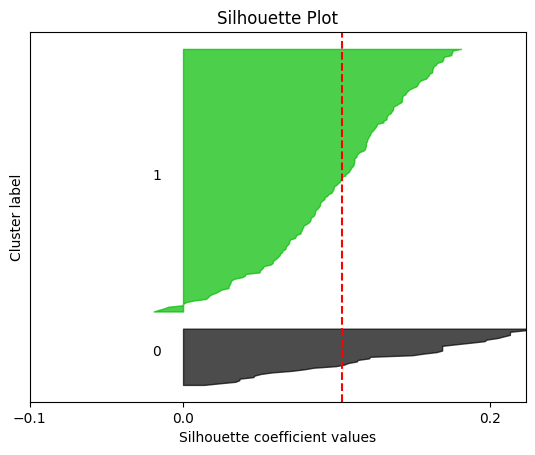

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


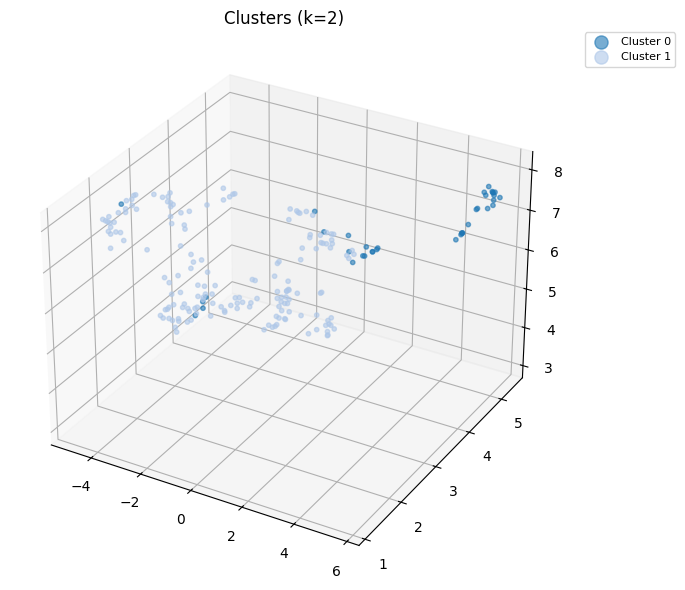


FOR NUM CLUSTERS 3 --------------------
score:  -57.10193634033203
distance score:  0.5163508
silhouette score:  0.06315132
balance score:  0.6893203883495145


/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['c', 'd'] not in stop_words.
  warnings.warn(


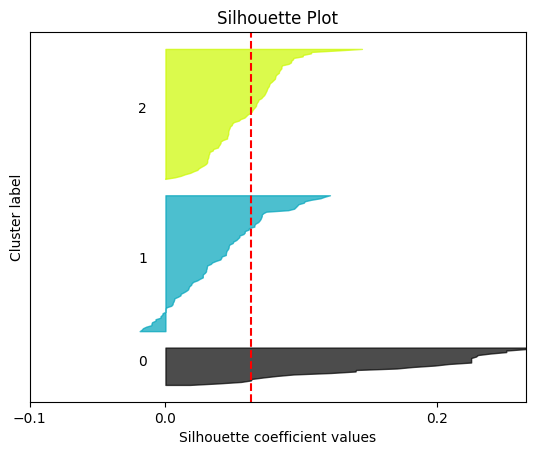

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


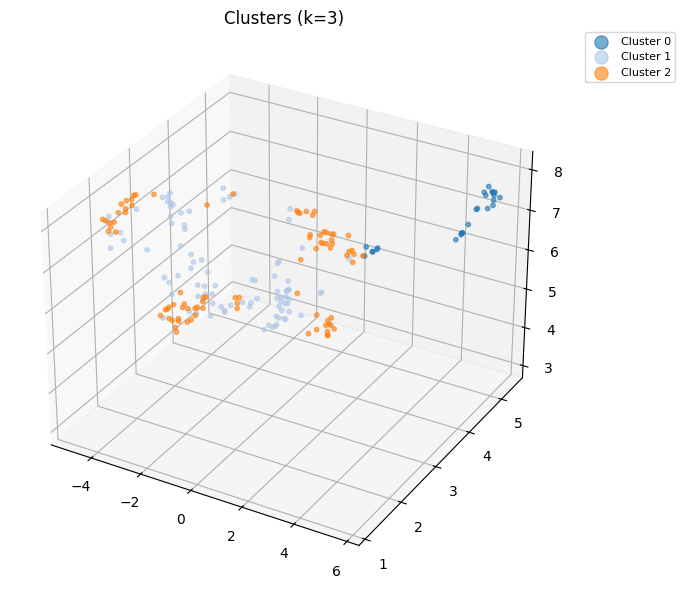

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['c', 'd'] not in stop_words.
  warnings.warn(



FOR NUM CLUSTERS 4 --------------------
score:  -54.48141098022461
distance score:  0.5065999
silhouette score:  0.07522803
balance score:  0.7993527508090615


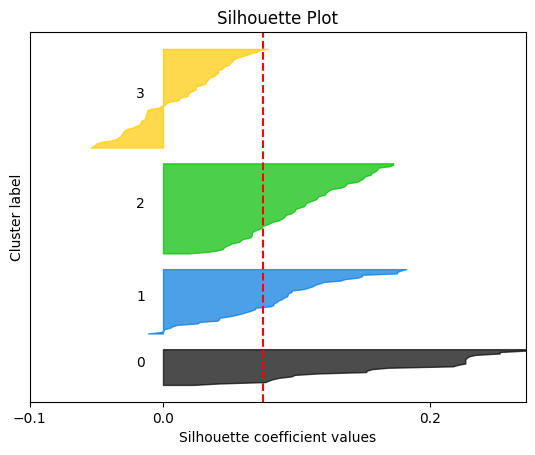

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


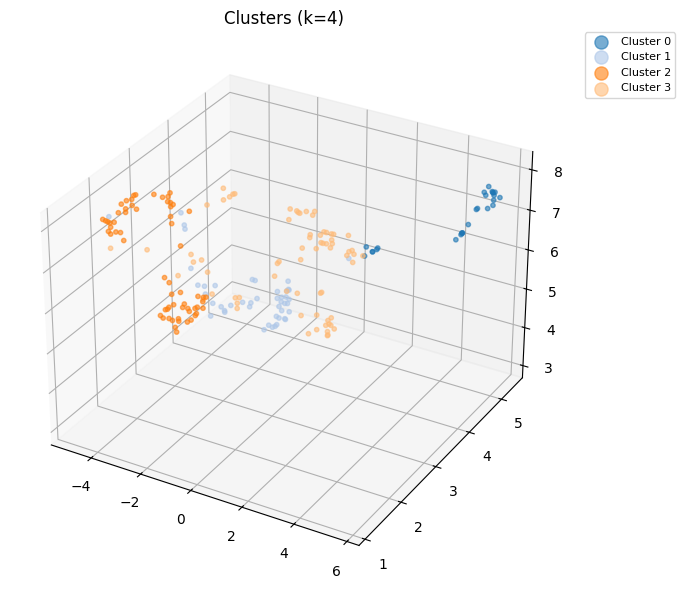

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['c', 'd'] not in stop_words.
  warnings.warn(



FOR NUM CLUSTERS 5 --------------------
score:  -51.51179885864258
distance score:  0.48912773
silhouette score:  0.08675509
balance score:  0.8155339805825242


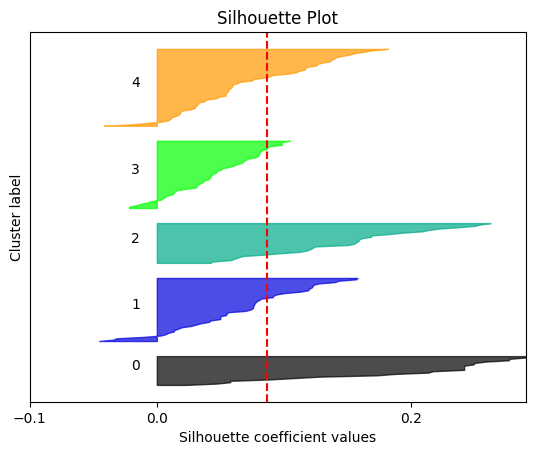

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


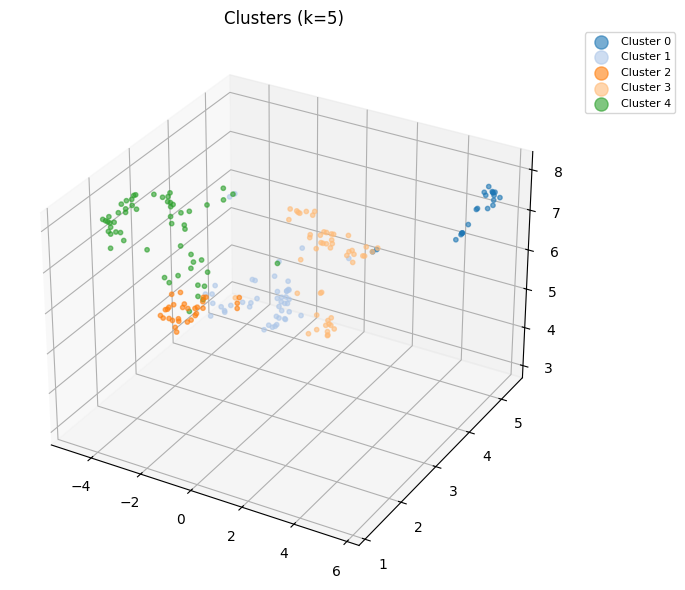

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['c', 'd'] not in stop_words.
  warnings.warn(



FOR NUM CLUSTERS 6 --------------------
score:  -50.29926681518555
distance score:  0.48490968
silhouette score:  0.088927075
balance score:  0.8135922330097087


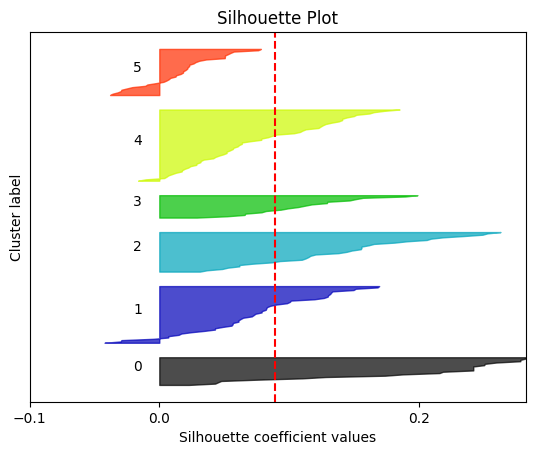

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


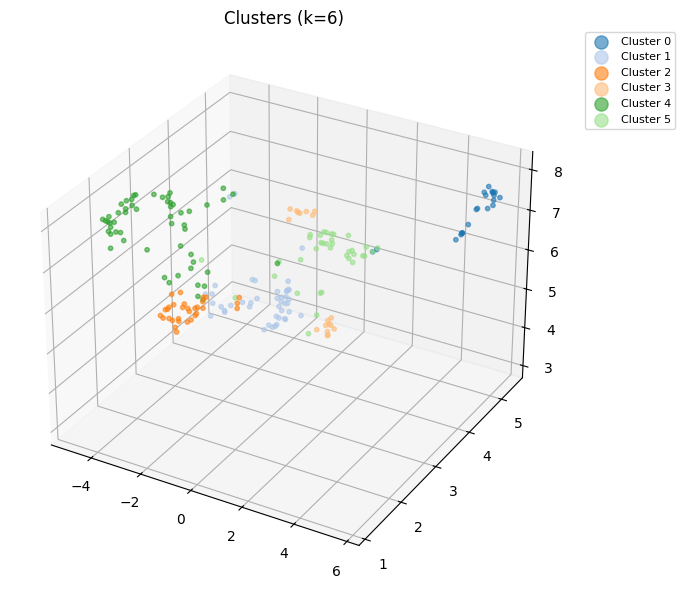

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['c', 'd'] not in stop_words.
  warnings.warn(



FOR NUM CLUSTERS 7 --------------------
score:  -49.3060188293457
distance score:  0.478534
silhouette score:  0.086785495
balance score:  0.761326860841424


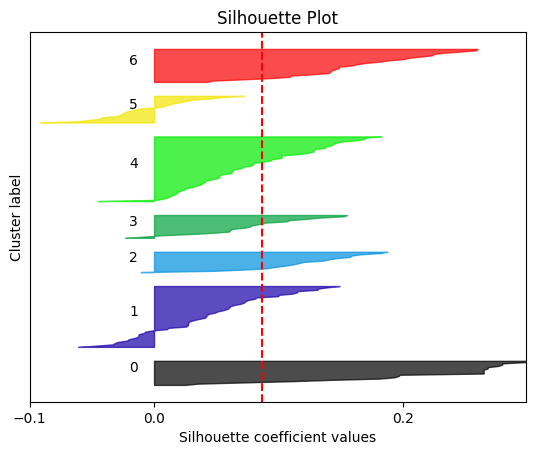

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


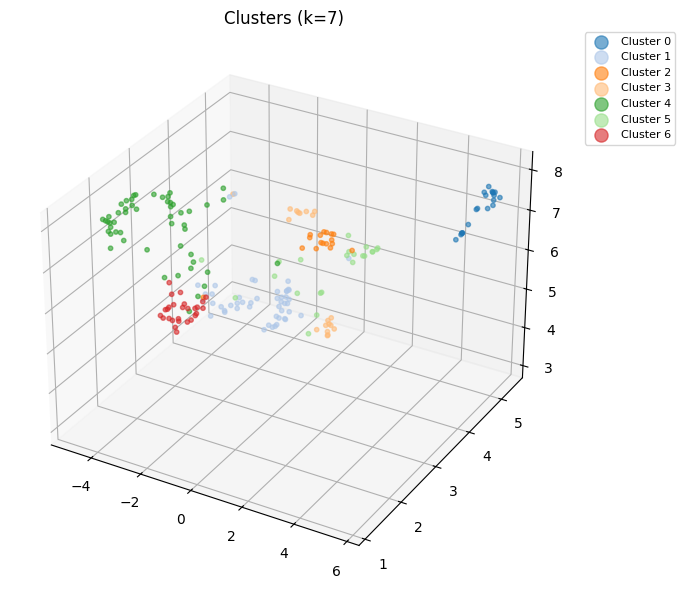


FOR NUM CLUSTERS 8 --------------------
score:  -48.10036849975586
distance score:  0.469706
silhouette score:  0.0797118
balance score:  0.8238557558945908


/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['c', 'd'] not in stop_words.
  warnings.warn(


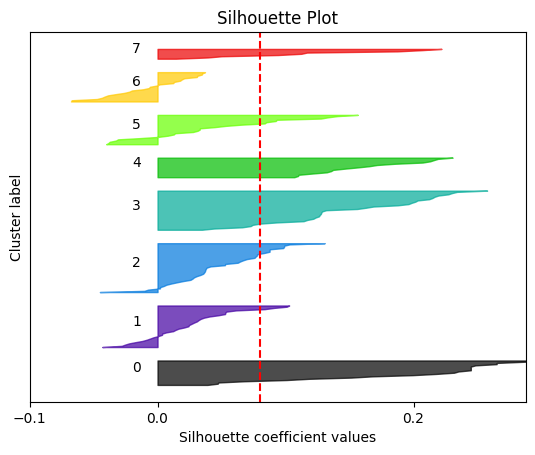

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


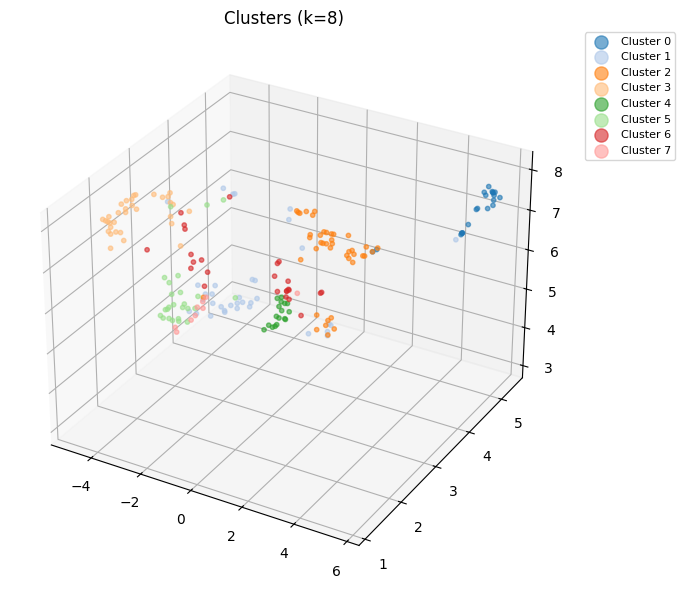

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['c', 'd'] not in stop_words.
  warnings.warn(



FOR NUM CLUSTERS 9 --------------------
score:  -46.66264343261719
distance score:  0.45929992
silhouette score:  0.081972785
balance score:  0.8282766990291263


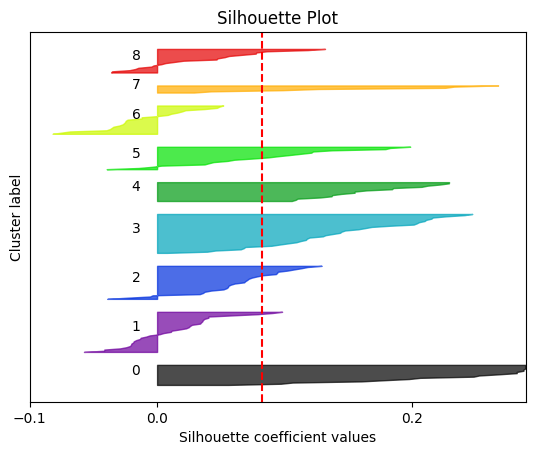

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


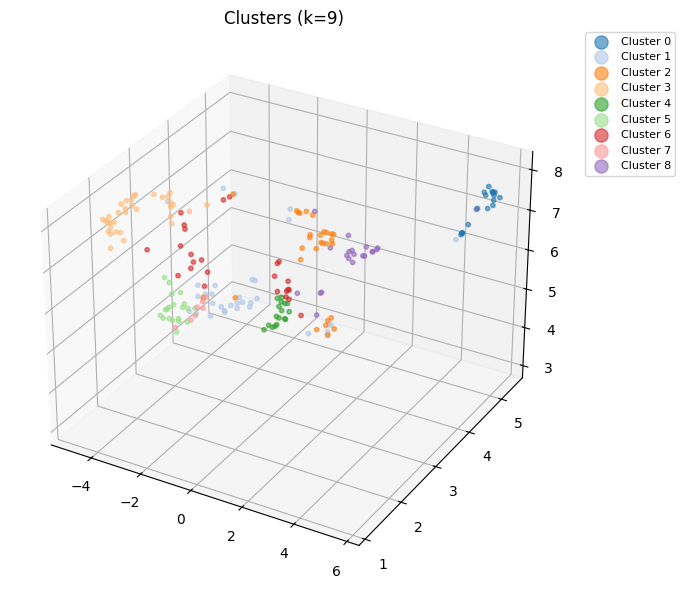

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['c', 'd'] not in stop_words.
  warnings.warn(



FOR NUM CLUSTERS 10 --------------------
score:  -45.24542999267578
distance score:  0.45039576
silhouette score:  0.09081099
balance score:  0.8327939590075513


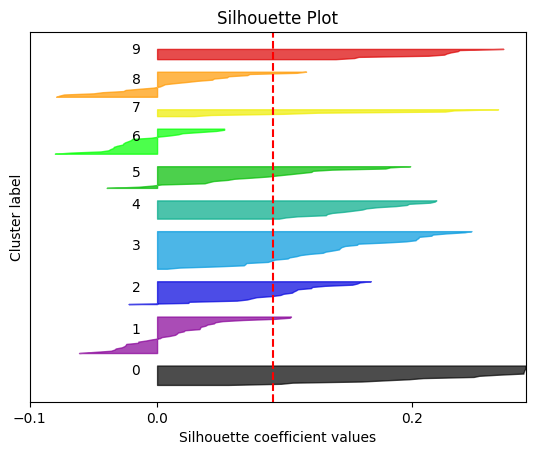

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


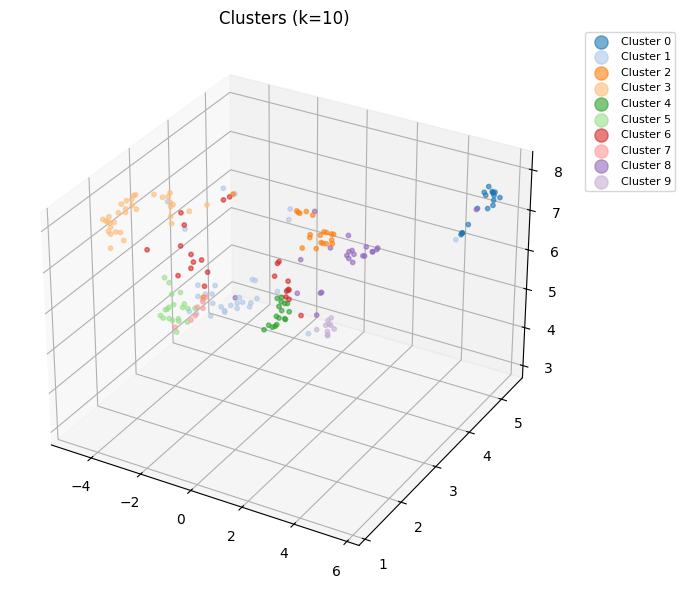

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['c', 'd'] not in stop_words.
  warnings.warn(



FOR NUM CLUSTERS 11 --------------------
score:  -44.15566635131836
distance score:  0.44669536
silhouette score:  0.0896972
balance score:  0.8470873786407767


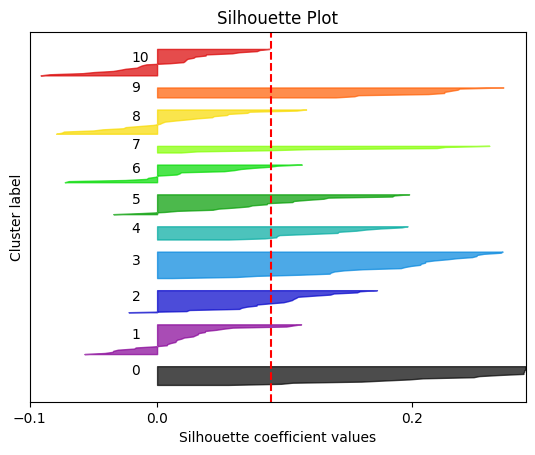

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


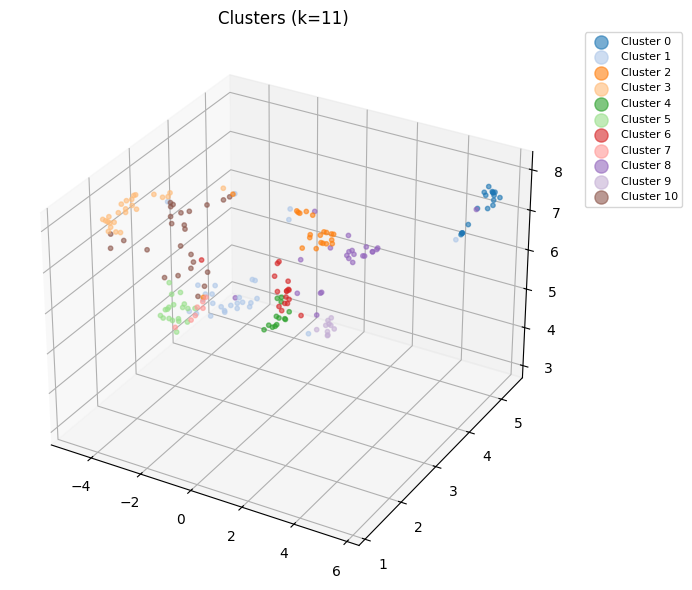

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['c', 'd'] not in stop_words.
  warnings.warn(



FOR NUM CLUSTERS 12 --------------------
score:  -43.30253982543945
distance score:  0.44540334
silhouette score:  0.09427939
balance score:  0.8146513680494263


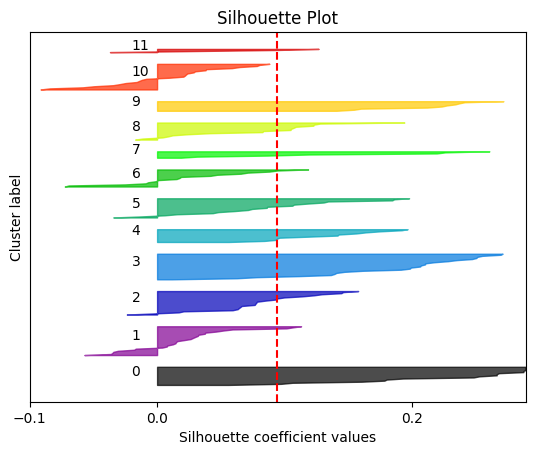

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


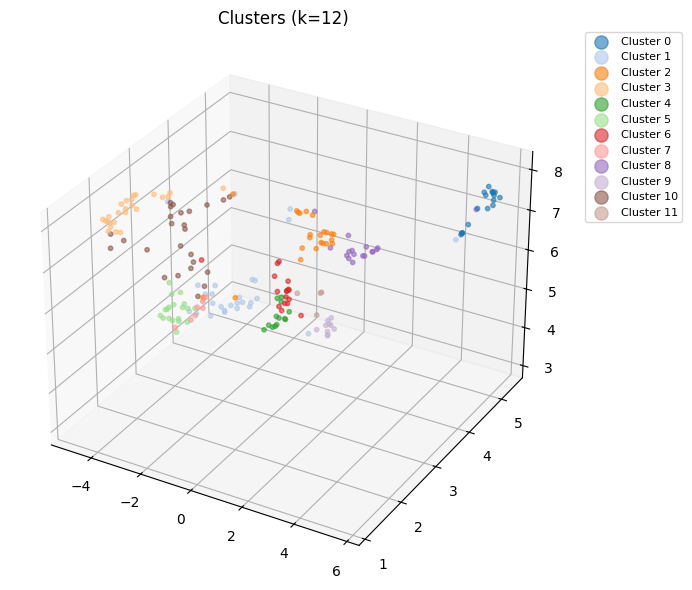

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['c', 'd'] not in stop_words.
  warnings.warn(



FOR NUM CLUSTERS 13 --------------------
score:  -43.009437561035156
distance score:  0.44631532
silhouette score:  0.08141312
balance score:  0.8313106796116505


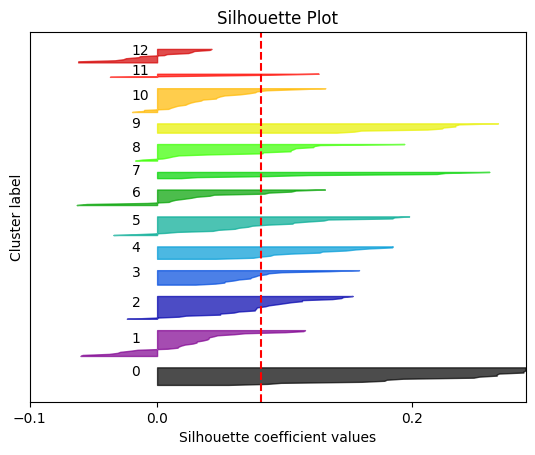

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


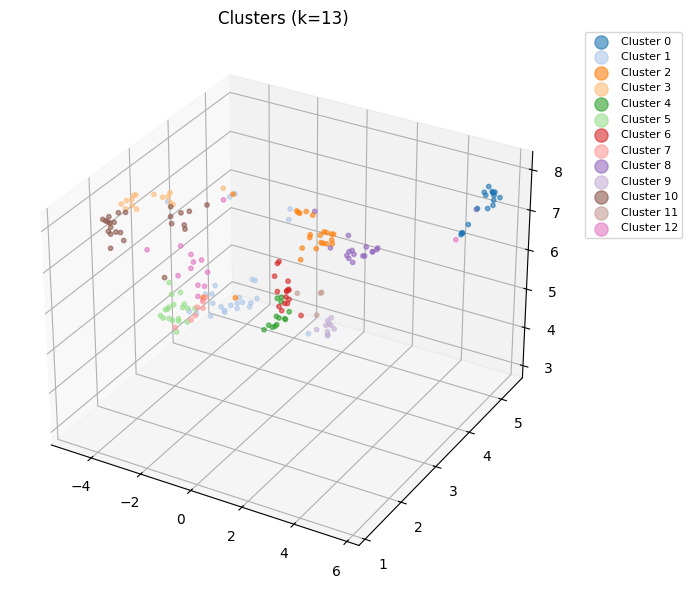

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['c', 'd'] not in stop_words.
  warnings.warn(



FOR NUM CLUSTERS 14 --------------------
score:  -41.839176177978516
distance score:  0.4358891
silhouette score:  0.08652177
balance score:  0.8155339805825244


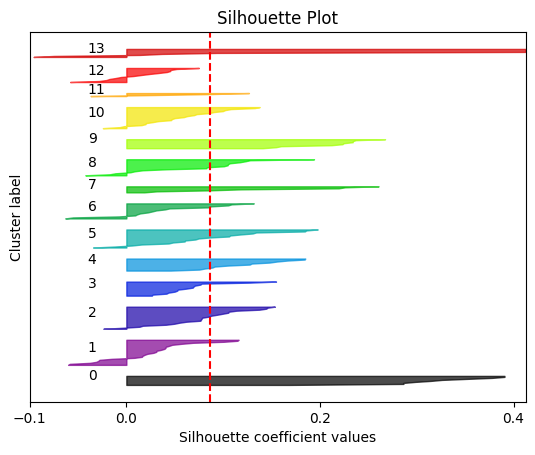

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


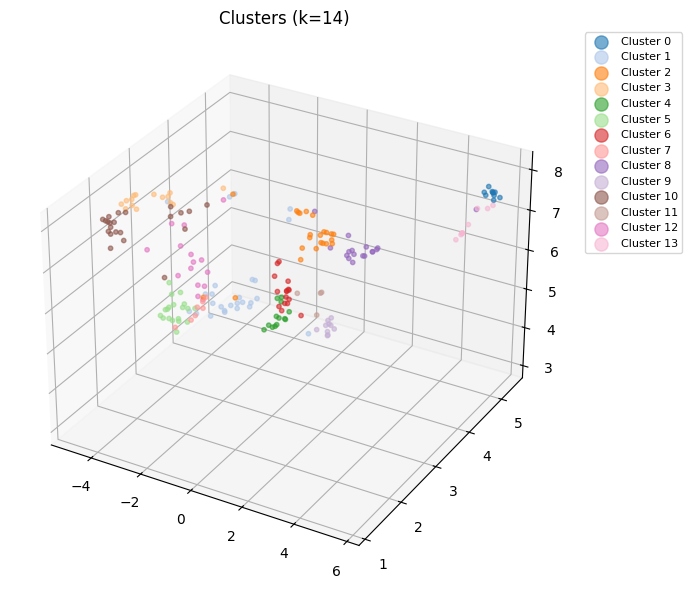

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['c', 'd'] not in stop_words.
  warnings.warn(



FOR NUM CLUSTERS 15 --------------------
score:  -41.52863693237305
distance score:  0.43277138
silhouette score:  0.087713555
balance score:  0.7770457697642164


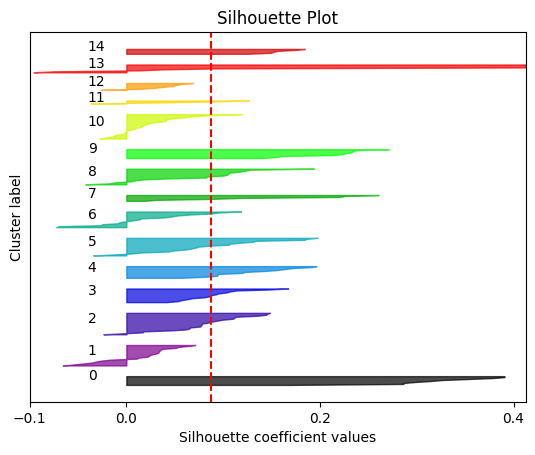

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


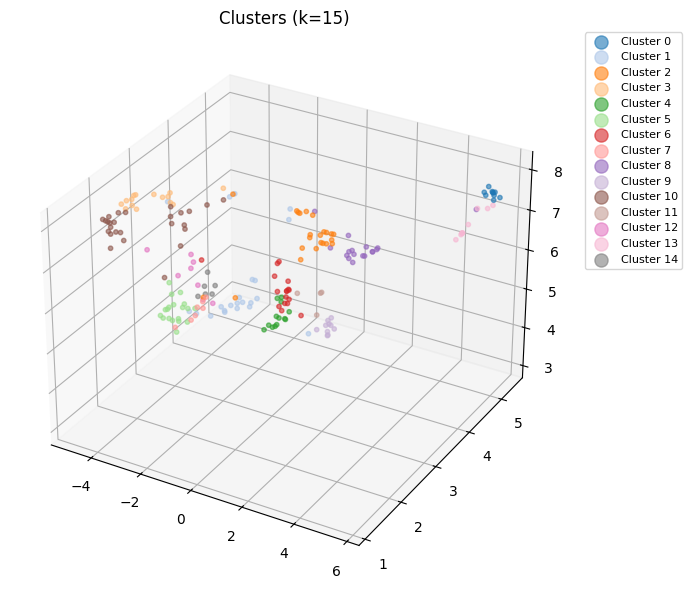

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['c', 'd'] not in stop_words.
  warnings.warn(


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloading: all_clusters_inst.json


In [161]:
all_json_data = []

# Execute loop
for k in range(2, 16):
    # 1. Cluster and Evaluate
    kmeans_model, labels = run_clustering_and_evaluate(inst_embeddings_np, k)

    # 2. Plot 3D
    plot_clusters_3d(inst_embeddings_np, labels, k, lookup_df)

    # 3. Examine distances and get closest points
    distances = examine_top_points(inst_embeddings_np, kmeans_model, labels, lookup_df, k)

    # 4. Get TF-IDF keywords
    keywords_dict = extract_cluster_keywords(lookup_df, labels, k, stop_words_for_cluster)

    # 5. Get Results DF
    results_df = get_cluster_results_df(lookup_df, labels, distances, k)

    # 6. Format for JSON
    cluster_list = []
    for c in range(k):
        c_str = str(c)
        cluster_data = results_df[results_df['cluster'] == c].to_dict(orient='records')
        cluster_list.append({
            "key": c_str,
            "keywords": keywords_dict.get(c_str, []),
            "data": cluster_data
        })

    all_json_data.append({
        "n": k,
        "clusters": cluster_list
    })

# Save all runs to a single JSON file
filename = 'all_clusters_inst.json'
with open(filename, 'w', encoding='utf-8') as f:
    json.dump(all_json_data, f, indent=4, ensure_ascii=False)

files.download(filename)
print(f"Saved and downloading: {filename}")